In [1583]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint

In [1584]:
fn_yaml = "config.yaml"

config = yaml.safe_load(open(fn_yaml, 'r'))
pprint(config)



{'derived_signals': {'sig4': {'equation': 'sig1 + sig2',
                              'signal_name': 'signal_4',
                              'units': 'F'}},
 'ramp_config': {'end_time': 200,
                 'hold_duration': {'max_value': 100, 'min_value': 0},
                 'ramp_duration': {'max_value': 50, 'min_value': 0},
                 'ramp_start_time': {'max_value': 100, 'min_value': 1}},
 'signals': {'sig1': {'max_rate_of_change': 10,
                      'max_value': 100,
                      'min_value': 0,
                      'no_change_probability': 0.3,
                      'signal_name': 'signal_1',
                      'units': 'F'},
             'sig2': {'max_rate_of_change': 10,
                      'max_value': 200,
                      'min_value': 0,
                      'no_change_probability': 0.3,
                      'signal_name': 'signal_2',
                      'units': 'F'},
             'sig3': {'max_rate_of_change': 100,
                 

In [1585]:


def get_sample(d, sample_type = 'uniform'):

    if sample_type == 'uniform':
        return np.random.uniform(d['min_value'], d['max_value'])
    else:
        raise ValueError(f"Unsupported sample_type: {sample_type}")

def generate_signal(signal_name, signal_config, ramp_config, end_time_pad = 1):


    initial_value = get_sample(signal_config)
    ramp_start_time = get_sample(ramp_config['ramp_start_time'])
    ramp_duration =  get_sample(ramp_config['ramp_duration'])
    end_time = ramp_config['end_time']
    hold_duration = get_sample(ramp_config['hold_duration'])

    if np.random.uniform(0, 1) > signal_config['no_change_probability']:
        ramp_rate = np.random.uniform(-signal_config['max_rate_of_change'], signal_config['max_rate_of_change'])
    else:
        ramp_rate = 0

    final_value = initial_value + ramp_rate * ramp_duration


    t0 = 0
    t1 = ramp_start_time
    t2 = t1 + ramp_duration
    t3 = t2 + hold_duration
    t4 = t3 + ramp_duration
    t5 = np.max([t4 + end_time_pad, end_time])

    y0 = initial_value
    y1 = initial_value
    y2 = final_value
    y3 = final_value
    y4 = initial_value
    y5 = initial_value

    t = np.array([t0, t1, t2, t3, t4, t5])
    y = np.array([y0, y1, y2, y3, y4, y5])

    y = np.clip(y, signal_config['min_value'], signal_config['max_value'])
    df = pd.DataFrame(index = t, data = {signal_name: y})

    if end_time not in df.index:
        df.loc[end_time] = np.nan
        df = df.sort_index()
        df = df.interpolate(method = 'index')

    I = df.index <= config['ramp_config']['end_time']
    df = df.loc[I]

    signal_range = df[signal_name].max() - df[signal_name].min()
    effectice_ramp_duration = np.abs(signal_range/ramp_rate) if ramp_rate != 0 else 0


    metadata = {
        'initial_value': initial_value,
        'ramp_start_time': ramp_start_time,
        'effectice_ramp_duration': effectice_ramp_duration,
        'ramp_rate': ramp_rate,
        'hold_duration': hold_duration,
        'signal_range': signal_range
    }
  
    return df, metadata


def generate_signals(config):

    dfs = []
    metadatas = {}

    for signal_name, signal_config in config['signals'].items():
        df, metadata = generate_signal(signal_name, signal_config, config['ramp_config'])
        dfs.append(df)
        metadatas[signal_name] = metadata

    df_merged = pd.concat(dfs, axis = 1)
    df_merged = df_merged.sort_index()
    df_merged = df_merged.interpolate(method = 'index')

    I = df_merged.index <= config['ramp_config']['end_time']
    df_merged = df_merged.loc[I]

    df_parameters = pd.DataFrame.from_dict(metadatas, orient='index')

    return df_merged, df_parameters


In [1586]:
df_merged, df_parameters = generate_signals(config)


print(df_merged)
print(df_parameters)

                 sig1        sig2        sig3
0.000000    18.010003  153.364689  132.228481
63.272830   18.010003  153.364689  132.228481
85.469457   18.010003  200.000000  132.228481
86.730251   18.010003  200.000000  132.228481
98.093978   18.010003  200.000000  132.228481
128.311133   4.463436  200.000000  132.228481
138.267333   0.000000  200.000000  132.228481
176.556441   0.000000  200.000000  132.228481
176.932062   0.000000  199.210815  132.228481
192.258451   0.000000  167.009935  132.228481
198.753067   2.911583  153.364689  132.228481
200.000000   3.470592  153.364689  132.228481
      initial_value  ramp_start_time  effectice_ramp_duration  ramp_rate  \
sig1      18.010003        98.093978                 4.153767  -4.335824   
sig2     153.364689        63.272830                 4.854191   9.607225   
sig3     132.228481        86.730251                 0.000000   0.000000   

      hold_duration  signal_range  
sig1      53.991118     18.010003  
sig2      91.086984     4

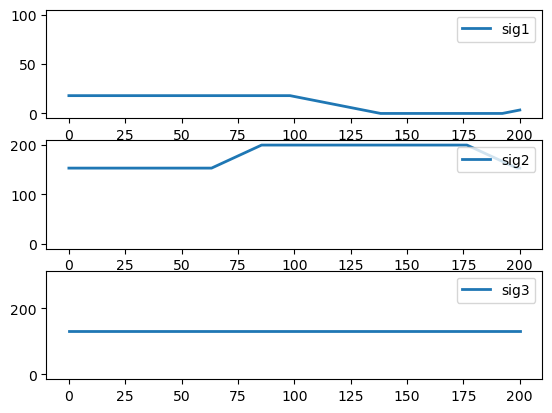

In [1587]:


fig, ax = plt.subplots(len(df_merged.columns))
for i, signal_name in enumerate(df_merged.columns):
    ax[i].plot(df_merged.index, df_merged[signal_name], label = f'{signal_name}', linewidth = 2)

    yrange = config['signals'][signal_name]['max_value'] - config['signals'][signal_name]['min_value']
    plot_min = config['signals'][signal_name]['min_value'] - 0.05 * yrange
    plot_max = config['signals'][signal_name]['max_value'] + 0.05 * yrange

    ax[i].set_ylim(plot_min, plot_max)
    ax[i].legend(loc = 1)

In [1588]:
df_merged


,sig1,sig2,sig3
0.000000,18.010003,153.364689,132.228481
63.272830,18.010003,153.364689,132.228481
85.469457,18.010003,200.000000,132.228481
86.730251,18.010003,200.000000,132.228481
98.093978,18.010003,200.000000,132.228481
128.311133,4.463436,200.000000,132.228481
138.267333,0.000000,200.000000,132.228481
176.556441,0.000000,200.000000,132.228481
176.932062,0.000000,199.210815,132.228481
192.258451,0.000000,167.009935,132.228481
